In [1]:
import pandas as pd

fff = pd.read_csv(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\FFF.csv")

print(fff.shape)
print(fff.columns.tolist())

(7762, 55)
['code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'date_registration', 'date_unregistration', 'ass_1_date', 'ass_1_score', 'ass_2_date', 'ass_2_score', 'ass_3_date', 'ass_3_score', 'ass_4_date', 'ass_4_score', 'ass_5_date', 'ass_5_score', 'ass_6_date', 'ass_6_score', 'ass_7_date', 'ass_7_score', 'ass_8_date', 'ass_8_score', 'ass_9_date', 'ass_9_score', 'ass_10_date', 'ass_10_score', 'ass_11_date', 'ass_11_score', 'ass_12_date', 'ass_12_score', 'clicks_dataplus', 'clicks_dualpane', 'clicks_folder', 'clicks_forumng', 'clicks_glossary', 'clicks_homepage', 'clicks_htmlactivity', 'clicks_oucollaborate', 'clicks_oucontent', 'clicks_ouelluminate', 'clicks_ouwiki', 'clicks_page', 'clicks_questionnaire', 'clicks_quiz', 'clicks_repeatactivity', 'clicks_resource', 'clicks_subpage', 'clicks_url']


In [3]:
demographics = ['gender', 'region', 'highest_education', 'imd_band', 'age_band',
                 'num_of_prev_attempts', 'studied_credits', 'disability']

assessment_cols = [f'ass_{i}_score' for i in range(1, 13)]

click_cols = ['clicks_dataplus', 'clicks_dualpane', 'clicks_folder', 'clicks_forumng',
              'clicks_glossary', 'clicks_homepage', 'clicks_htmlactivity', 'clicks_oucollaborate',
              'clicks_oucontent', 'clicks_ouelluminate', 'clicks_ouwiki', 'clicks_page',
              'clicks_questionnaire', 'clicks_quiz', 'clicks_repeatactivity', 'clicks_resource',
              'clicks_subpage', 'clicks_url']

selected_cols = demographics + assessment_cols + click_cols + ['final_result']

fff_sel = fff[selected_cols].copy()
print(fff_sel.shape)
fff_sel.head()

(7762, 39)


,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,ass_1_score,ass_2_score,...,clicks_ouelluminate,clicks_ouwiki,clicks_page,clicks_questionnaire,clicks_quiz,clicks_repeatactivity,clicks_resource,clicks_subpage,clicks_url,final_result
0,F,South East Region,A Level or Equivalent,30-40%,0-35,0,60,N,86.0,94.0,...,42.0,54.0,15.0,26.0,848.0,NaN,44.0,380.0,50.0,Distinction
1,M,Wales,A Level or Equivalent,80-90%,35-55,0,60,N,94.0,78.0,...,0.0,19.0,9.0,18.0,460.0,NaN,24.0,198.0,25.0,Pass
2,M,South West Region,A Level or Equivalent,10-20,0-35,0,60,N,86.0,82.0,...,0.0,18.0,10.0,18.0,536.0,NaN,25.0,165.0,25.0,Pass
3,M,West Midlands Region,Lower Than A Level,70-80%,0-35,0,120,Y,84.0,66.0,...,4.0,0.0,7.0,0.0,286.0,NaN,13.0,54.0,11.0,Withdrawn
4,M,South Region,Lower Than A Level,40-50%,0-35,0,90,N,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Withdrawn


In [5]:
print("imd_band unique values:")
print(fff_sel['imd_band'].unique())
print()
print("imd_band NaN count:", fff_sel['imd_band'].isna().sum())
print()
print("NaN counts - assessment scores:")
print(fff_sel[assessment_cols].isna().sum())
print()
print("NaN counts - click columns:")
print(fff_sel[click_cols].isna().sum())

imd_band unique values:
['30-40%' '80-90%' '10-20' '70-80%' '40-50%' nan '60-70%' '50-60%' '0-10%'
 '90-100%' '20-30%']

imd_band NaN count: 367

NaN counts - assessment scores:
ass_1_score     1536
ass_2_score     2222
ass_3_score     3011
ass_4_score     3373
ass_5_score     3891
ass_6_score     2812
ass_7_score     3174
ass_8_score     3519
ass_9_score     3627
ass_10_score    3714
ass_11_score    3694
ass_12_score    3802
dtype: int64

NaN counts - click columns:
clicks_dataplus           670
clicks_dualpane           670
clicks_folder            4301
clicks_forumng            670
clicks_glossary           670
clicks_homepage           670
clicks_htmlactivity      5641
clicks_oucollaborate     2180
clicks_oucontent          670
clicks_ouelluminate      6252
clicks_ouwiki             670
clicks_page               670
clicks_questionnaire      670
clicks_quiz               670
clicks_repeatactivity    3543
clicks_resource           670
clicks_subpage            670
clicks_url        

In [7]:
fff_sel['imd_band'] = fff_sel['imd_band'].replace('10-20', '10-20%')

imd_mode = fff_sel['imd_band'].mode()[0]
print("imd_band mode:", imd_mode)
fff_sel['imd_band'] = fff_sel['imd_band'].fillna(imd_mode)

print(fff_sel['imd_band'].unique())

fff_sel[assessment_cols] = fff_sel[assessment_cols].fillna(-1)
fff_sel[click_cols] = fff_sel[click_cols].fillna(0)

print(fff_sel.isna().sum().sum())

imd_band mode: 30-40%
['30-40%' '80-90%' '10-20%' '70-80%' '40-50%' '60-70%' '50-60%' '0-10%'
 '90-100%' '20-30%']
0


In [9]:
final_result_map = {'Withdrawn': 0, 'Fail': 1, 'Pass': 2, 'Distinction': 3}
fff_sel['final_result'] = fff_sel['final_result'].map(final_result_map)

highest_ed_order = ['No Formal quals', 'Lower Than A Level', 'A Level or Equivalent',
                     'HE Qualification', 'Post Graduate Qualification']
highest_ed_map = {v: i for i, v in enumerate(highest_ed_order)}
fff_sel['highest_education'] = fff_sel['highest_education'].map(highest_ed_map)

imd_order = ['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50-60%',
             '60-70%', '70-80%', '80-90%', '90-100%']
imd_map = {v: i for i, v in enumerate(imd_order)}
fff_sel['imd_band'] = fff_sel['imd_band'].map(imd_map)

age_band_order = ['0-35', '35-55', '55<=']
age_band_map = {v: i for i, v in enumerate(age_band_order)}
fff_sel['age_band'] = fff_sel['age_band'].map(age_band_map)

fff_sel['gender'] = fff_sel['gender'].map({'M': 0, 'F': 1})
fff_sel['disability'] = fff_sel['disability'].map({'N': 0, 'Y': 1})

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
fff_sel['region'] = le.fit_transform(fff_sel['region'])

print(fff_sel.isna().sum().sum())
print(fff_sel.dtypes)

0
gender                     int64
region                     int64
highest_education          int64
imd_band                   int64
age_band                   int64
num_of_prev_attempts       int64
studied_credits            int64
disability                 int64
ass_1_score              float64
ass_2_score              float64
ass_3_score              float64
ass_4_score              float64
ass_5_score              float64
ass_6_score              float64
ass_7_score              float64
ass_8_score              float64
ass_9_score              float64
ass_10_score             float64
ass_11_score             float64
ass_12_score             float64
clicks_dataplus          float64
clicks_dualpane          float64
clicks_folder            float64
clicks_forumng           float64
clicks_glossary          float64
clicks_homepage          float64
clicks_htmlactivity      float64
clicks_oucollaborate     float64
clicks_oucontent         float64
clicks_ouelluminate      float64
clicks_o

In [11]:
for col in click_cols:
    nonzero = (fff_sel[col] != 0).sum()
    unique_vals = fff_sel[col].nunique()
    print(f"{col}: {nonzero} nonzero / {unique_vals} unique values")

clicks_dataplus: 2326 nonzero / 91 unique values
clicks_dualpane: 2648 nonzero / 41 unique values
clicks_folder: 1934 nonzero / 14 unique values
clicks_forumng: 6741 nonzero / 1263 unique values
clicks_glossary: 701 nonzero / 59 unique values
clicks_homepage: 7084 nonzero / 1223 unique values
clicks_htmlactivity: 1918 nonzero / 26 unique values
clicks_oucollaborate: 3172 nonzero / 72 unique values
clicks_oucontent: 6946 nonzero / 2481 unique values
clicks_ouelluminate: 1211 nonzero / 109 unique values
clicks_ouwiki: 5423 nonzero / 208 unique values
clicks_page: 6251 nonzero / 65 unique values
clicks_questionnaire: 3792 nonzero / 66 unique values
clicks_quiz: 6226 nonzero / 1540 unique values
clicks_repeatactivity: 3 nonzero / 4 unique values
clicks_resource: 6686 nonzero / 192 unique values
clicks_subpage: 6948 nonzero / 827 unique values
clicks_url: 6376 nonzero / 182 unique values


In [13]:
click_cols_final = [c for c in click_cols if c != 'clicks_repeatactivity']

fff_sel['total_clicks'] = fff_sel[click_cols_final].sum(axis=1)
fff_sel = fff_sel.drop(columns=click_cols)  # drops all 18, including repeatactivity

bin_cols = assessment_cols + ['total_clicks']

for col in bin_cols:
    binned = pd.qcut(fff_sel[col], q=4, duplicates='drop')
    n_bins = binned.nunique()
    print(f"{col}: {n_bins} bins")
    fff_sel[col] = binned.cat.codes

print()
print("Final shape:", fff_sel.shape)
print(fff_sel.columns.tolist())

ass_1_score: 4 bins
ass_2_score: 3 bins
ass_3_score: 3 bins
ass_4_score: 3 bins
ass_5_score: 2 bins
ass_6_score: 3 bins
ass_7_score: 3 bins
ass_8_score: 3 bins
ass_9_score: 3 bins
ass_10_score: 3 bins
ass_11_score: 3 bins
ass_12_score: 3 bins
total_clicks: 4 bins

Final shape: (7762, 22)
['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score', 'ass_5_score', 'ass_6_score', 'ass_7_score', 'ass_8_score', 'ass_9_score', 'ass_10_score', 'ass_11_score', 'ass_12_score', 'final_result', 'total_clicks']


In [15]:
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.graph.GraphNode import GraphNode
import numpy as np

data = fff_sel.values.astype(float)
node_names = fff_sel.columns.tolist()

nodes = {name: GraphNode(name) for name in node_names}

assessment_cols_fff = [f'ass_{i}_score' for i in range(1, 13)]
demo_vars = ['gender', 'region', 'highest_education', 'imd_band', 'age_band',
             'num_of_prev_attempts', 'studied_credits', 'disability']
course_time_vars = assessment_cols_fff + ['total_clicks', 'final_result']

bk = BackgroundKnowledge()

# Rule 1
for ct in course_time_vars:
    for d in demo_vars:
        bk.add_forbidden_by_node(nodes[ct], nodes[d])

# Rule 2
for name in node_names:
    if name != 'gender':
        bk.add_forbidden_by_node(nodes[name], nodes['gender'])

# Rule 3
for i in range(1, 13):
    for j in range(1, 13):
        if j > i:
            bk.add_forbidden_by_node(nodes[f'ass_{j}_score'], nodes[f'ass_{i}_score'])

# Rule 4
for ct in course_time_vars:
    bk.add_forbidden_by_node(nodes[ct], nodes['studied_credits'])
    bk.add_forbidden_by_node(nodes[ct], nodes['num_of_prev_attempts'])

# Rule 5
for a in assessment_cols_fff:
    bk.add_forbidden_by_node(nodes['final_result'], nodes[a])

# Rule 6
for a in assessment_cols_fff:
    bk.add_forbidden_by_node(nodes[a], nodes['total_clicks'])

# Rule 7
bk.add_forbidden_by_node(nodes['final_result'], nodes['total_clicks'])

cg = pc(data, alpha=0.05, indep_test='gsq', background_knowledge=bk, node_names=node_names)

print("PC complete.")
print("Number of edges:", cg.G.get_num_edges())

  0%|          | 0/22 [00:00<?, ?it/s]

PC complete.
Number of edges: 78


In [17]:
edges = cg.G.get_graph_edges()
for edge in edges:
    print(edge)

gender --> studied_credits
gender --> total_clicks
highest_education --> region
imd_band --> region
region --- disability
region --> ass_1_score
imd_band --> highest_education
age_band --> highest_education
highest_education --> disability
imd_band --> disability
age_band --> total_clicks
num_of_prev_attempts --> studied_credits
ass_1_score --> ass_2_score
ass_1_score --> ass_3_score
ass_1_score --> ass_4_score
ass_1_score --> final_result
total_clicks --> ass_1_score
ass_2_score --> ass_3_score
ass_2_score --> ass_4_score
ass_2_score --> ass_5_score
ass_2_score --> ass_6_score
ass_2_score --> ass_8_score
ass_2_score --> final_result
total_clicks --> ass_2_score
ass_3_score --> ass_4_score
ass_3_score --> ass_5_score
ass_3_score --> ass_6_score
ass_3_score --> ass_7_score
ass_3_score --> ass_8_score
ass_3_score --> ass_9_score
ass_3_score --> final_result
total_clicks --> ass_3_score
ass_4_score --> ass_5_score
ass_4_score --> ass_7_score
ass_4_score --> ass_8_score
ass_4_score --> ass

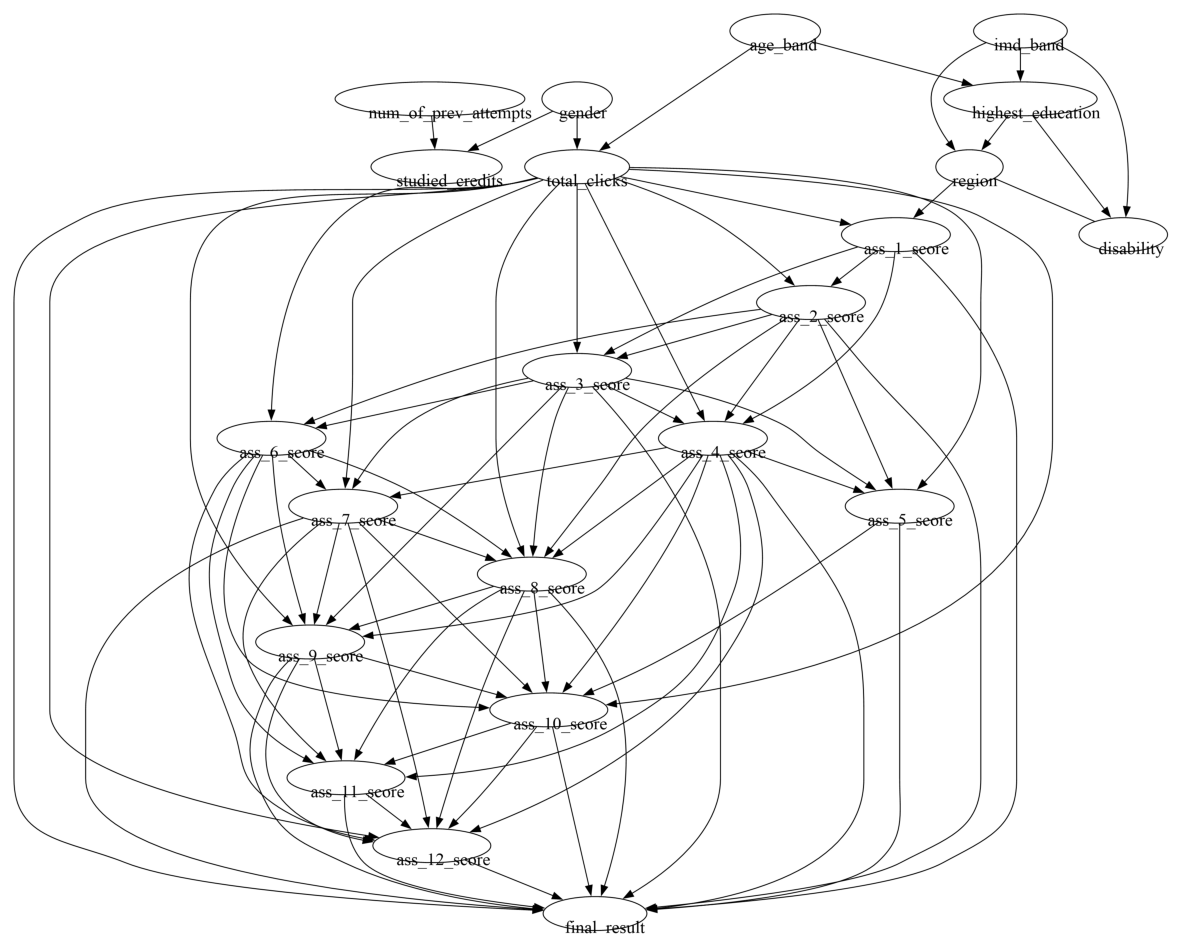

In [19]:
from causallearn.utils.GraphUtils import GraphUtils
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import io

dot_path = r"C:\Users\Disha Sharma\.conda\envs\analytics\Library\bin\dot.exe"

pyd = GraphUtils.to_pydot(cg.G, labels=node_names)
png_data = pyd.create_png(prog=dot_path)

img = mpimg.imread(io.BytesIO(png_data))
plt.figure(figsize=(16, 12))
plt.imshow(img)
plt.axis('off')
plt.show()